# Student Performance EDA

- Importing Libraries

In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

- Loading Dataset

In [ ]:
data = pd.read_csv("Dataset.csv")

- Dataset Overview

In [105]:
print("-------------- Summary Analysis Report of Dataset --------------\n")
print("No. of Categorical Columns are:",data.select_dtypes(include=["object","string"]).shape[1])
print("----------------------------------------")
print("No. of Numerical Columns are:",data.select_dtypes(include=["number"]).shape[1])
print("----------------------------------------")
print("Unique values in dataset are:\n ",data.nunique())
print("----------------------------------------")
print("Shape of dataset is:",data.shape)
print("----------------------------------------")
print("Maximum value from all numerical columns are:\n",data[["math score","reading score","writing score"]].max())
print("----------------------------------------")
print("Minimum value from all numerical columns are:\n",data[["math score","reading score","writing score"]].min())
print("----------------------------------------")
print("Statistical summary of dataset:\n",data.describe())

-------------- Summary Analysis Report of Dataset --------------

No. of Categorical Columns are: 5
----------------------------------------
No. of Numerical Columns are: 3
----------------------------------------
Unique values in dataset are:
  gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64
----------------------------------------
Shape of dataset is: (1000, 8)
----------------------------------------
Maximum value from all numerical columns are:
 math score       100
reading score    100
writing score    100
dtype: int64
----------------------------------------
Minimum value from all numerical columns are:
 math score        0
reading score    17
writing score    10
dtype: int64
----------------------------------------
Statistical summary of dataset:

- Feature Engineering

In [106]:
# Adding a new column named total score
data["total_score"] = data[["math score","reading score","writing score"]].sum(axis=1)

# Adding another new column named average score
data["average_score"] = data[["math score","reading score","writing score"]].mean(axis=1)

# Adding another new column named Performance labeled
conditions = [
    (data["average_score"] <= 40),
    ((data["average_score"] > 40) & (data["average_score"] <= 70)),
    ((data["average_score"] > 70) & (data["average_score"] <= 100))
    ]
labels = ["Low","Medium","High"]
data["Performance_labeled"] = np.select(conditions, labels,default="unknown")


## Performing EDA with help of plots

- Melting the data (Combining the subject scores for better visualization.)

Insight: The boxplot compares the score distributions across math, reading, and writing. It highlights the median performance, spread of scores, and outliers, helping in identify variations in student performance across subjects.


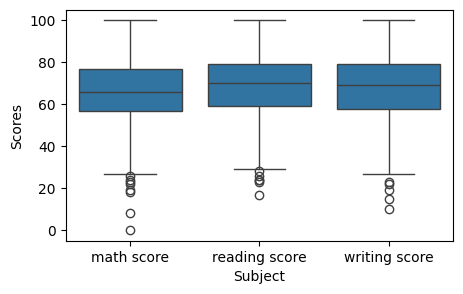

In [125]:
melted_data = data.melt(
    id_vars = "gender",
    value_vars=["math score","reading score","writing score"],
    var_name="Subject",
    value_name="Scores")
plt.figure(figsize=(5,3))
sns.boxplot(data=melted_data,x="Subject",y="Scores")
print("Insight: The boxplot compares the score distributions across math, reading, and writing. It highlights the median performance, spread of scores, and outliers, helping in identify variations in student performance across subjects.")


- Score Distribution

Insight: We can see that math score is almost symmetric with a bit of left skewness.Also the reading and writing scores are also a bit left skewed. We can see there is more variance around top in reading and writing score in comparison to math score.


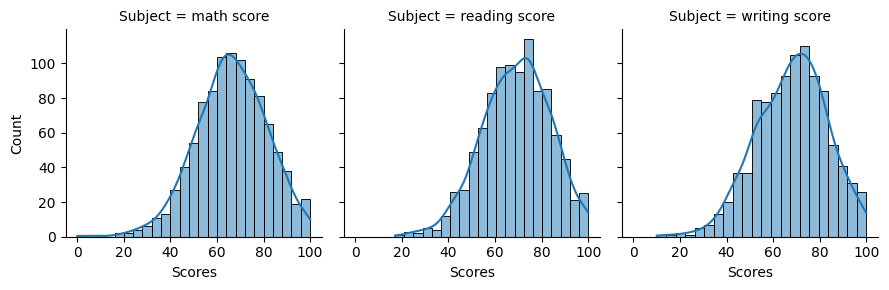

In [126]:
g = sns.FacetGrid(melted_data, col="Subject")
g.map_dataframe(sns.histplot, "Scores", kde=True)
print("Insight: We can see that math score is almost symmetric with a bit of left skewness.Also the reading and writing scores are also a bit left skewed. We can see there is more variance around top in reading and writing score in comparison to math score.")

- Detecting the outliers

In [114]:
def Outlier_detection(data):
    numeric_col = data.select_dtypes(include=["number"]).columns
    for col in numeric_col:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5*IQR
        upper_limit = Q3 + 1.5*IQR
        outliers = data[(data[col] < lower_limit) | (data[col] > upper_limit)]
        print(f"\nColumn: {col}")
        print(f"Lower Limit: {lower_limit}")
        print(f"Upper Limit: {upper_limit}")
        print("Outliers are:\n",outliers.values)
        print(f"Number of Outliers: {len(outliers)}")
        print(f"Outlier Percentage: {(len(outliers)/len(data))*100:.2f}%")
Outlier_detection(data)



Column: math score
Lower Limit: 27.0
Upper Limit: 107.0
Outliers are:
 [['female' 'group B' 'some high school' 'free/reduced' 'none' 18 32 28 78
  26.0 'Low']
 ['female' 'group C' 'some high school' 'free/reduced' 'none' 0 17 10 27
  9.0 'Low']
 ['female' 'group C' 'some college' 'free/reduced' 'none' 22 39 33 94
  31.333333333333332 'Low']
 ['female' 'group B' 'some high school' 'free/reduced' 'none' 24 38 27 89
  29.666666666666668 'Low']
 ['female' 'group D' "associate's degree" 'free/reduced' 'none' 26 31 38
  95 31.666666666666668 'Low']
 ['female' 'group B' 'some college' 'standard' 'none' 19 38 32 89
  29.666666666666668 'Low']
 ['female' 'group B' 'high school' 'free/reduced' 'completed' 23 44 36
  103 34.333333333333336 'Low']
 ['female' 'group B' 'high school' 'free/reduced' 'none' 8 24 23 55
  18.333333333333332 'Low']]
Number of Outliers: 8
Outlier Percentage: 0.80%

Column: reading score
Lower Limit: 29.0
Upper Limit: 109.0
Outliers are:
 [['female' 'group C' 'some high s

- Correlation Matrix

Insight: The matrix shows high positive relationship amongst all three variables.reading and writing scores are highly correlated amongst themselves incomparison to their individual relation with math score.


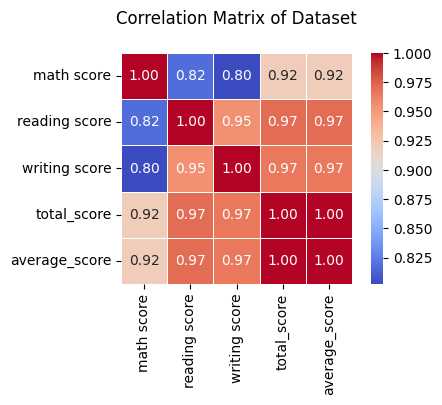

In [128]:
corr_mat = data.corr(numeric_only=True)
plt.figure(figsize=(5,3))
sns.heatmap(corr_mat,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,square=True)
plt.title("Correlation Matrix of Dataset\n")
print("Insight: The matrix shows high positive relationship amongst all three variables.reading and writing scores are highly correlated amongst themselves incomparison to their individual relation with math score.")

- Subject-wise Performance Comparison

Insight: The no. of outliers are greater for female students in comparison of male students.Also, the median value of scores for female candidates are higher in comparison of male students.


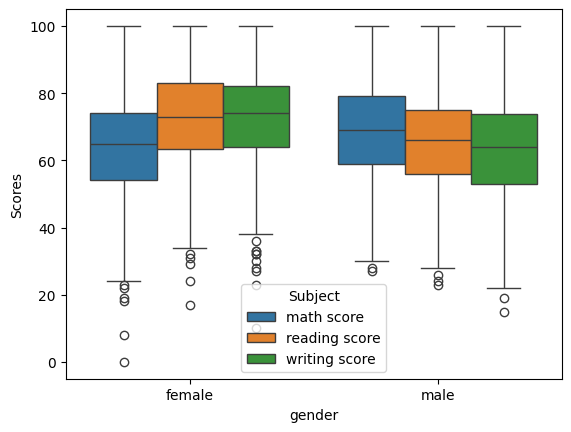

In [132]:
plt.Figure(figsize=(10,8))
sns.boxplot(data=melted_data,x="gender",y="Scores",hue="Subject")
print("Insight: The no. of outliers are greater for female students in comparison of male students.Also, the median value of scores for female candidates are higher in comparison of male students.")

- Gender Based Performance

Genderdized average scores are:
         math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31
Insight:Female students generally achieve higher median scores in reading and writing, while math scores show a smaller difference between genders.


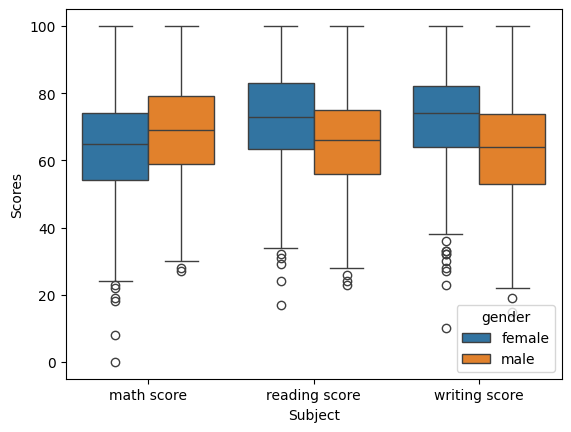

In [ ]:
print("Genderdized average scores are:\n",data.groupby("gender")[["math score","reading score","writing score"]].mean().round(2))
sns.boxplot(data=melted_data,x="Subject",y="Scores",hue="gender")
print("Insight:Female students generally achieve higher median scores in reading and writing, while math scores show a smaller difference between genders.")

- Showcasing relationship between scores

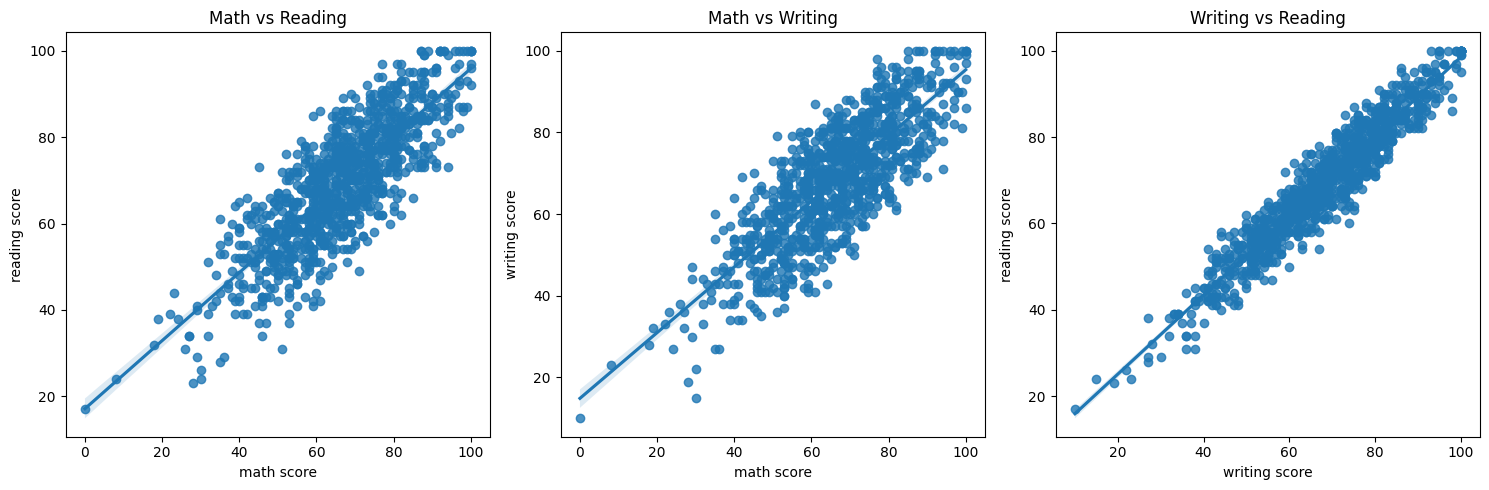

Insight: All three subjects show positive relationships with one another. The strongest relationship exists between reading and writing scores, while math scores also show positive but slightly more dispersed relationships with the other two subjects. This suggests that language-related skills (reading and writing) are more closely related compared to math.


In [135]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.regplot(data=data, x="math score", y="reading score", ax=axes[0])
axes[0].set_title("Math vs Reading")
sns.regplot(data=data, x="math score", y="writing score", ax=axes[1])
axes[1].set_title("Math vs Writing")
sns.regplot(data=data, x="writing score", y="reading score", ax=axes[2])
axes[2].set_title("Writing vs Reading")
plt.tight_layout()
plt.show()
print("Insight: All three subjects show positive relationships with one another. The strongest relationship exists between reading and writing scores, while math scores also show positive but slightly more dispersed relationships with the other two subjects. This suggests that language-related skills (reading and writing) are more closely related compared to math.")
